<h1>CSE2530 Computational Intelligence</h1>
<h2>Assignment 2: Artificial Neural Networks</h2>
    
|    Group   |           61          |
|------------|----------------------|
| Student A  |        Eva Miesen (5705304) |
| Student B  |        Iasonas Chronis (6167608) |
| Student C  |        Guy Barel (6124607) |
| Student D  |        Miłosz Duduła (6212743) |

<h4>Imports</h4>

In [23]:
# You may only use numpy to implement your neural network
# You are not allowed to use scikit-learn, other than for Section 1.6.
# You are also not allowed to use Pytorch, Tensorflow, and similar machine learning frameworks.
# You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.

# Put all of your imports in this code block
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy

<h4>Seed</h4>

In [24]:
# We use fixed seed to ensure reproducibility of our results
# NOTE: im not sure if this is what they mean "to ensure reproducibility"
# np.random.seed(10)
# according to tas, the np random is just a collection of random numbers
# so if we retrain the network we will get a different random initial value from the list
# but if we rerun the notebook multiple times over the same seed set, we will get the same results (in plural, as in we will get the same final weights from all the different training runs of the network)
# the convention is seed 42

<h4>Loading the data</h4>

In [25]:
features = np.genfromtxt("../data/features.txt", delimiter=",") # 7854 samples of 10 features
targets = np.genfromtxt("../data/targets.txt", delimiter=",")   # 7854 target classes of the samples mentioned above
unknown = np.genfromtxt("../data/unknown.txt", delimiter=",")   # 784 samples of 10 features, with no lables available

In [26]:
# 80-20 train-test split to have a reserved test set
np.random.seed(42)  # For reproducibility
indices = np.arange(features.shape[0])
np.random.shuffle(indices)

split = int(0.8 * features.shape[0])
train_indices = indices[:split]
test_indices = indices[split:]

# Training data (80%)
features_train = features[train_indices]
targets_train = targets[train_indices]

# Test data (20%) 
features_test = features[test_indices]
targets_test = targets[test_indices]

print(f"Training set size: {features_train.shape[0]}")
print(f"Test set size: {features_test.shape[0]}")

# --- create fixed validation split from the training portion ---
# we reserve 20% of the 80% training set as a validation subset that will
# be used throughout the notebook for hyperparameter tuning
np.random.seed(0)  # separate seed so validation set stays consistent across runs
train_idx_sub = np.arange(features_train.shape[0])
np.random.shuffle(train_idx_sub)
sub_split = int(0.8 * features_train.shape[0])
train_sub_indices = train_idx_sub[:sub_split]
val_sub_indices = train_idx_sub[sub_split:]

features_train_sub = features_train[train_sub_indices]
targets_train_sub = targets_train[train_sub_indices]

features_val_sub = features_train[val_sub_indices]
targets_val_sub = targets_train[val_sub_indices]

print(f"Training‑subset size: {features_train_sub.shape[0]}")
print(f"Validation‑subset size: {features_val_sub.shape[0]}")

Training set size: 6283
Test set size: 1571
Training‑subset size: 5026
Validation‑subset size: 1257


<h3>Architecture</h3>
<h4>Question 1</h4>

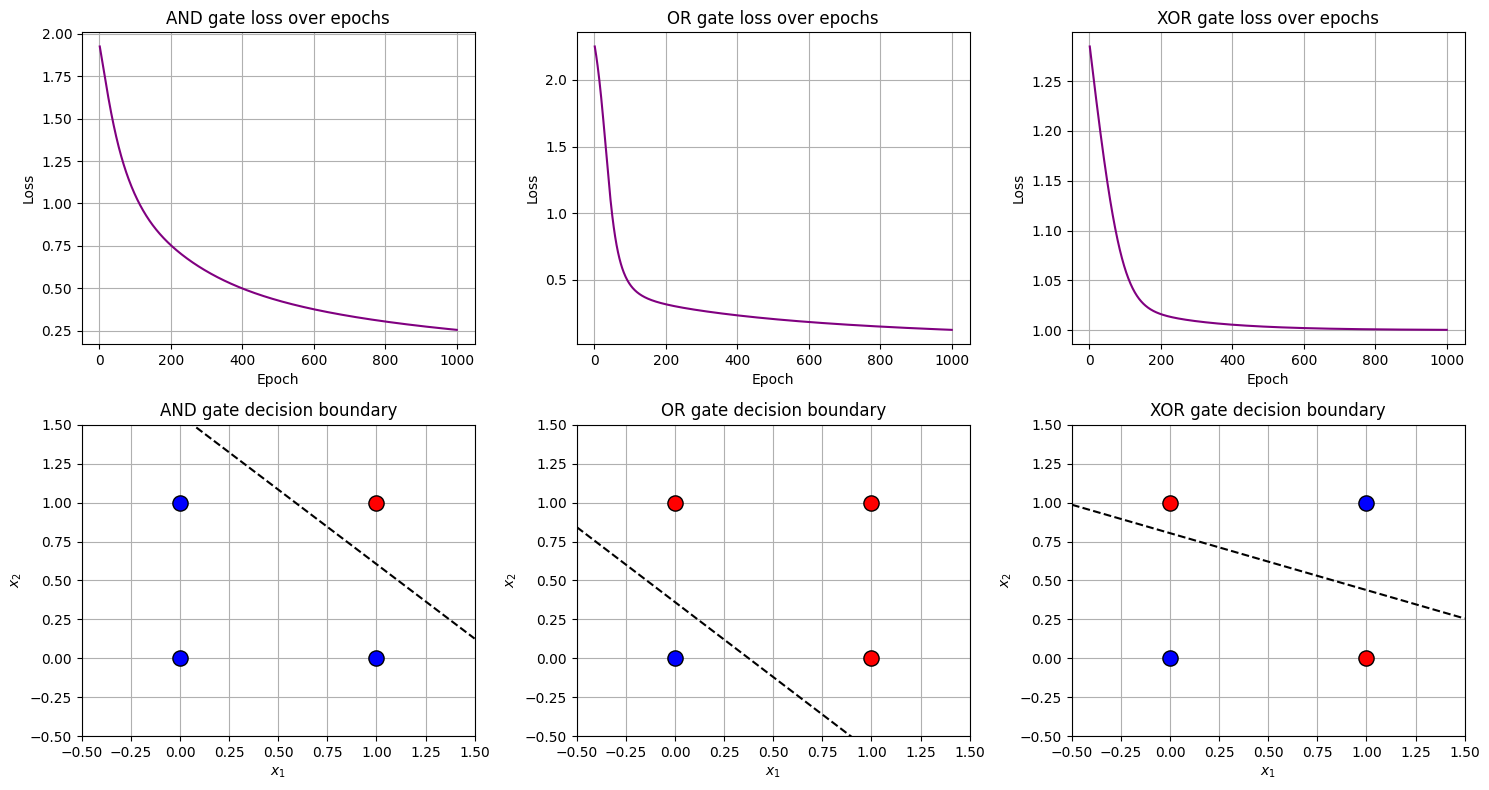

In [27]:
# Inputs
logic_gates = {
    "AND": {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 0, 0, 1]},
    "OR":  {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 1, 1, 1]},
    "XOR": {"x": [[0,0],[0,1],[1,0],[1,1]], "y": [0, 1, 1, 0]},
}

# Functions
def sigmoid(z):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    """Derivative of the sigmoid function."""
    s = sigmoid(z)
    return s * (1 - s)

def forward(X, w, b):
    """Forward pass: computes pre-activation z and activation h = sigmoid(z)."""
    z = X @ w + b
    h = sigmoid(z)
    return z, h

def loss(y, h):
    """Mean squared error loss."""
    return np.sum((y - h) ** 2)

def backward(X, y, h, z):
    """Backward pass: computes gradients dw and db using the chain rule."""
    m = X.shape[0]
    dL_dz = -2 * (y - h) * sigmoid_derivative(z)
    dw = (X.T @ dL_dz) / m
    db = np.sum(dL_dz) / m
    return dw, db

def train_perceptron(X, y, epochs=1000, lr=0.1):
    """Trains a single perceptron with sigmoid activation using gradient descent.

    Returns: (w, b, loss_history)
    """
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float).reshape(-1, 1)

    # Initialize weights and bias
    w = np.random.randn(X.shape[1], 1)
    b = np.random.randn()
    loss_history = []

    # Training loop
    for _ in range(epochs):
        z, h = forward(X, w, b)
        loss_history.append(loss(y, h))
        dw, db = backward(X, y, h, z)
        w -= lr * dw
        b -= lr * db

    return w, b, loss_history

# Train and plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (name, gate) in enumerate(logic_gates.items()):
    # Train perceptron
    X = np.array(gate["x"], dtype=float)
    y = np.array(gate["y"], dtype=float)
    w, b, losses = train_perceptron(gate["x"], gate["y"])

    # Loss over epochs
    ax_loss = axes[0, col]
    epochs = np.arange(1, len(losses) + 1)
    ax_loss.plot(epochs, losses, color="purple")
    ax_loss.set_title(f"{name} gate loss over epochs")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.grid(True)

    # Decision boundaries
    ax_decision = axes[1, col]

    # Plot data points
    for i in range(len(y)):
        color = "red" if y[i] == 1 else "blue"
        ax_decision.scatter(X[i, 0], X[i, 1], c=color, s=120, edgecolors="k", zorder=3)

    # Plot decision boundary
    w0, w1 = w.flatten()
    x_line = np.linspace(-0.5, 1.5, 200)
    if abs(w1) > 1e-10:
        ax_decision.plot(x_line, -(w0 * x_line + b) / w1, "k--")
    else:
        ax_decision.axvline(x=-b / w0, color="k", linestyle="--")

    ax_decision.set_xlim(-0.5, 1.5)
    ax_decision.set_ylim(-0.5, 1.5)
    ax_decision.set_xlabel("$x_1$")
    ax_decision.set_ylabel("$x_2$")
    ax_decision.set_title(f"{name} gate decision boundary")
    ax_decision.grid(True)

plt.tight_layout()
plt.show()

For `OR` and `AND` gates the loss curve approaches zero and the final decision boundary cleanly separates the two classes. This shows that the perceptron successfully learned a linear separator that matches the corresponding truth table.

On the other hand, for the `XOR` gate, the loss decreases montonically but plateaus at 1. The final decision boundary fails to separate the opposing classing, showing the `XOR` is not linearly separable. Thus a single preceptron cannot represent an `XOR` gate.

<h4>Question 2: How many input neurons are needed in our classification task as described above? </h4>


The number of input neurons is fixed by the number of features in the input data. Since we have 10 features, we need 10 input neurons.

<h4>Question 3: How many output neurons do you require?</h4>

The number of output neurons is fixed by the task type. Since the task is to classify objects into multiple separate classes, one ouput neuron per class is required. Since there are 7 classes, the network will have 7 output neurons.

<h4>Question 4: How many hidden neurons and layers will your network have?

The number of hidden neurons and layers is determined by balancing the dataset complexity, available computational power, and the risk of overfitting. Our dataset consists of 10 meaningful, human-designed features per sample and is of moderate size. Given this, a network with 1 hidden layer is a reasonable starting point, as a second layer would only be needed if the patterns are more complex or hierarchical.

There is no strict formula for choosing the numnber of neurons in a hidden layers, but common heuristics provide guidance. Two widely used rules are the "between the input and output size" rule and the "2/3 rule".

The first suggests a number between the input and output size, in our case that would mean: (input + output)/2 = (10 + 7)/2 ≈ 8 neurons. The 2/3 rule gives (2/3) * input + output = (2/3) * 10 + 7 ≈ 14. These values are usually enough to learn simple patterns, but may not capture more subtle feature interactions.

To provide extra capacity while maintaining computational efficiency, we decided to roughly double the heuristic values, giving 30 neurons. Following standard practice of using powers of 2, we rounded this to 32 neurons.

During experimentation, if the network underfits (fails to learn the patterns), the number of neurons can be increased, and if it overfits (memorises the training data), they can be reduced. A second hidden layer can be added if the network struggles to capture more complex or hierarchical relationships.

<h4>Question 5: Which activation function(s) will you use?</h4>

The neural network will use Leaky Rectified Linear Unit (ReLU) for the hidden layer and Softmax for the output layer.

ReLU is effective, because it enables fast learning, avoids vanishing gradients, and efficiently handles the 10 input features. Leaky ReLU is a variant of ReLU that allows a small slope for negative inputs, preventing dead neurons (neurons that output 0 for all inputs), which can otherwise slow down training.

The Softmax function converts raw outputs into probabilities that sum into 1, making it ideal for multiclass classifiction, as required in this assignment. It is similar to the Sigmoid function used for binary classification, but generalised for multiple classes. Softmax is also smooth and differentiable everywhere, which is necessary for backpropagation.

<h4>Question 6: Give a schematic diagram of your complete network based on your previous answers</h4>

![ANN Architecture](ANN%20Architecture.jpg)

NOTE: only the first and second neurons are connected to avoid overwhelming lines, we believe they sufficiently portrey a layer is fully connected.

AI was used to convert a sketch of the architecture into a polished $\LaTeX$ diagram.

<h3>Training</h3>

When coding a neural network from scratch, it helps to think of a layer as an individual component that can be easily combined with other layers. To help you create a modular implementation of a neural network, we provide you with a template for the implementation along with some explanations.

**Note that using the template below is not mandatory. You may choose to modify this template or implement your own version of the neural network altogether. If the latter, please remove our template from the notebook and ensure that it instead includes a complete, fully functional implementation of your own.**

**Linear (fully connected) layer**

A linear or fully connected layer maps the input data to an output by performing a linear transformation, where each input neuron is connected to every output neuron. The forward pass of a linear layer is computed as $y = wx + b$, where $w$ and $b$ are trainable parameters. The gradients of the loss with respect to $w$ and $b$ are defined using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial w}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial w}, \quad \frac{\partial \mathcal{L}}{\partial b}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial b}, $$

where $\frac{\partial \mathcal{L}}{\partial y}$ is the upstream gradient i.e., the gradient flowing from deeper layers into the current layer, and the other two terms are the local gradients:

$$
\frac{\partial y}{\partial w}=x, \quad \frac{\partial y}{\partial b}=1.
$$

Since $x$ is needed to compute the gradients, we can store (cache) its value during the forward pass. Finally, we need to return a downstream gradient so that more shallow layers can use it as their upstream gradient. The downstream gradient of a layer is simply its upstream gradient multiplied by the local gradient of its ouput with respect to its input:

$$
\frac{\partial \mathcal{L}}{\partial x}=\frac{\partial \mathcal{L}}{\partial y} \cdot \frac{\partial y}{\partial x}
$$

**Note.** Be aware of how you multiply the arrays, it might be useful to print the shapes of each array and to think about the desired shape of the output.  

In [28]:
# Despite the instruction above suggesting x to be just one input. We make our program so that it allows batches of x at a time to speed up. 
class Linear:
    def __init__(self, in_features, out_features, init_mode_weight=1, init_mode_bias=0):
        """ Randomly initialize the weights and biases.

        Args:
            in_features: number of input features.
            out_features: number of output features.
            init_mode_weight: mode of initialization for weights, we support:
              0 = all weights to zeroes (pointless but just to find out that then network does not work)
              1 = He initialization (common choice for ReLU)
              2 = Xavier initialization (rather preferred for sigmoid, but we'll try nevertheless)
              3 = Gaussian distribution
              4 = Uniform distribution: U(-0.05, 0.05)
            init_mode_bias: mode of bias initialization:
              0 = all zeroes (usual choice)
              1 = bias initialized accordingly to weight mode (U(-var, var)), 
                I don't think this is necessary but we are asked to randomly initialize the weights AND BIASES
        """
        self.bias = np.zeros((out_features))

        # Initialize weights
        if init_mode_weight == 0:
            self.weight = np.zeros((out_features, in_features))
        elif init_mode_weight == 1:
            std = np.sqrt(2/in_features)
        elif init_mode_weight == 2:
            std = np.sqrt(1/in_features)
        elif init_mode_weight == 3:
            std = 1
        elif init_mode_weight == 4:
            self.weight = np.random.uniform(-0.05, 0.05, (out_features, in_features))
            if init_mode_bias == 1:
                self.bias = np.random.uniform(-0.05, 0.05, (out_features)) 

        # If weights are not initialized to 0 or 4, initialize from normal distribution
        if init_mode_weight != 0 and init_mode_weight != 4:
            self.weight = np.random.normal(0.0, std, (out_features, in_features))
            if init_mode_bias == 1:
                self.bias = np.random.uniform(-std, std, (out_features)) 
        
        # Initialize cache, weight_grad, and bias_grad
        self.cache = None
        # For storing the gradients w.r.t. the weight and the bias
        self.weight_grad = None
        self.bias_grad = None

    def forward(self, x):
        """ Perform the forward pass of a linear layer. 
        Store (cache) the input so it can be used in the backward pass.

        Args:
            x: input of a linear layer.

        Returns: 
            y: output of a linear layer. 
        """
        self.cache = x
        y = x @ self.weight.T + self.bias

        return y
    
    def backward(self, dupstream):
        """ Perform the backward pass of a linear layer.  

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        self.weight_grad = (dupstream.T @ self.cache) / self.cache.shape[0] # we divide by batch size to keep the learning rate independent of batch_size
        self.bias_grad = np.sum(dupstream, axis=0) / self.cache.shape[0] 
        dx = dupstream @ self.weight
       
        return dx

**Activation functions**

You also need to implement an activation function suitable for the task at hand.

Think about how to perform the backward pass i.e., what is the local gradient and what the downstream gradient should be. Do not forget to take the upstream gradient into account.

In [29]:
class Activation:
    def __init__(self, alpha=0.01):
        self.cache = None
        self.alpha = alpha
    
    def forward(self, x):
        """ Perform a forward pass of your activation function.
        Store (cache) the output so it can be used in the backward pass.

        Args:
            x: input to the activation function. 

        Returns:
            y: output of the activation function.
        """
        self.cache = np.where(x > 0, x, self.alpha * x)
        
        return self.cache
    
    def backward(self, dupstream): 
        """ Perform a backward pass of the activation function. 
        Make sure you do not modify the original dupstream.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        mask = np.where(self.cache > 0, 1, self.alpha)
        dx = mask * dupstream

        return dx

**Network** 

Now that you have implemented a `Linear` layer and an activation function, you can combine them in different ways and have the `Network` class perform forward and backward passes through all layer of the network in the specified order.

Additionally, you should make the `Network` class update all the trainable parameters of the network in `optimizer_step`.

In [30]:
class Network:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        """ Perform a forward pass over the entire network.

        Args:
            x: input data. 

        Returns:
            y: predictions.
        """
        for layer in self.layers:
            x = layer.forward(x)
        
        return x
    
    def backward(self, dupstream):
        """ Perform a backward pass over the entire network.

        Args:
            dupstream: upstream gradient. 

        Returns:
            dx: downstream gradient.
        """
        for layer in reversed(self.layers):
            dupstream = layer.backward(dupstream)
        
        return dupstream
    
    def optimizer_step(self, lr):
        """ Update the weight and bias parameters of each layer.

        Args:
            lr: learning rate.
        """
        
        for layer in self.layers:
            if (isinstance(layer, Linear)):
                layer.weight -= lr * layer.weight_grad
                layer.bias -= lr * layer.bias_grad

**Loss function**

You also need to implement a loss function that will measure how well your neural network performs at the task.

In [31]:
def Loss(y_true, y_pred):
    """ Computes the value of the loss function and its gradient.  

    Args:
        y_true: ground truth labels.
        y_pred: predicted labels.

    Returns:
        loss: value of the loss. 
        grad: gradient of loss with respect to the predictions. 
    """
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10) # we do that to avoid log(0)
    loss = - np.mean(np.sum(y_true * np.log(y_pred), axis=1)) # we use mean to be consistent with weight gradients update
    grad = (- y_true / y_pred)

    return loss, grad

**Training loop**

Finally, define a training loop in which for each optimizer step you:

1. Obtain the predictions by performing a forward pass of the network;

2. Compute the loss and its gradient by comparing the predictions with the ground truth according to the selected criterion;

3. Perform a backward pass of the network;

4. Update all parameters of the network i.e, take an optimizer step.

In [32]:
# We create these two helper functions, as we reuse the code later for k_fold. 
def softmax(z):
    """
    Applies the softmax activation function to input array z.

    Args:
        z (np.ndarray): Input array of shape (batch_size, num_classes).

    Returns:
        np.ndarray: Output array after applying softmax, same shape as z.
    """
    shifted_z = z - np.max(z, axis=1, keepdims=True) # suggested by AI to keep exponents in softmax small. TODO: Explain why it works
    return np.exp(shifted_z) / np.sum(np.exp(shifted_z), axis=1, keepdims=True)

def calculate_accuracy(y_pred, y_true):
    # This also calculates false positives and false negatives which is needed for later. 
    y_predicted = np.argmax(y_pred, axis=1)
    y_true_class = np.argmax(y_true, axis=1)
    accuracy =  np.mean(y_predicted == y_true_class)

    # We calculate number of false positives and of false negatives per each of 7 classes.
    fp = np.zeros(7)
    fn = np.zeros(7)

    # Calculate false positives and false negatives
    for i in range(7):
        fp[i] = np.sum((y_predicted == i) & (y_true_class != i)) # We use bitwise AND here
        fn[i] = np.sum((y_predicted != i) & (y_true_class == i))
    return accuracy, fp, fn



def train(net, inputs, labels, criterion, lr, batch_size=0, epochs=1000, threshold = 1e-4, steps_to_stop = 20):
    """
    Trains the neural network.

    Args:
        net: network or model. 
        inputs: input data.
        labels: labels. 
        criterion: loss function.
        lr: learning rate.
        batch_size: batch size. Note: we add this to experiment with mini-batch updates

    Returns:
        losses: a list containing the loss at every optimizer step. 
        accuracies: a list containing the accuracy at every optimizer step. 
    """
    losses = []
    accuracies = []

    # If batch size is 0, set it to the number of samples in the input data
    if batch_size == 0:
        batch_size = inputs.shape[0]

    steps = 0
    prev_accuracy = 1073741823 # max int / 2 

    # Training loop
    for epoch in range(epochs):
        indices = np.random.choice(inputs.shape[0], batch_size, replace=False) # choosing random indices for this batch
        x_batch = inputs[indices]
        
        # Following 2 lines is an AI suggested debug. Previously we were taking y_batch = labels[indices], 
        # but our network expects e.g. [0, 0, 1, 0, 0, 0, 0] instead of label 3 
        y_indices = labels[indices].astype(int) - 1 # we adjust for indexing from 0
        y_batch = np.eye(7)[y_indices]

        # Forward pass
        z = net.forward(x_batch)
        y_pred = softmax(z)
        
        # Compute loss and gradient
        loss, grad = criterion(y_batch, y_pred)
        losses.append(loss)

        grad_after = (y_pred - y_batch) # suggested by AI, we need to find gradient of categorical cross-entropy combined with softmax, apparently it simplifies to this
        net.backward(grad_after)
        net.optimizer_step(lr)

        accuracy, _, _ = calculate_accuracy(y_pred, y_batch)
        accuracies.append(accuracy)

        # If accuracy change between two epochs is very small, then we end the training
        if abs(prev_accuracy - accuracy) < threshold:
            steps += 1
        else:
            steps = 0
        if steps > steps_to_stop:
            break
        
        prev_accuracy = accuracy
    return losses, accuracies

<h4>Question 7</h4>

#TODO:: discuss


In [33]:
# NOTE: k-fold cross-validation helper.  The main experiments in this
# notebook now use a fixed training/validation split and no longer call this
# function, but we keep it here for historical reference.
def k_fold_cross_validation(net, inputs, labels, criterion, lr=0.05, batch_size=0, k=5, epochs=500):
    """
    Perform k-fold cross-validation for a given neural network model.

    Args:
        net: Neural network to train and evaluate.
        inputs (np.ndarray): Input data.
        labels (np.ndarray): Class labels (integers 1..7).
        criterion: Loss function.
        lr (float): Learning rate.
        batch_size (int): Batch size.
        k (int): Number of folds.
        epochs (int): Training epochs per fold.

    Returns:
        list: List of validation accuracies from each fold.
    """
    indices = np.arange(inputs.shape[0])
    np.random.shuffle(indices)

    folds = np.array_split(indices, k)
    val_accuracies = []

    for i in range(k):
        net_i = copy.deepcopy(net)

        # Validation indices for this fold
        val_indices = folds[i]

        # Training indices are all other folds
        train_indices = []
        for j in range(k):
            if i != j:
                train_indices.append(folds[j])
        train_indices = np.concatenate(train_indices)

        x_train = inputs[train_indices]
        x_val = inputs[val_indices]

        # Use raw class labels for training (train() converts them to one-hot internally)
        labels_train = labels[train_indices]

        # One-hot encode validation labels
        labels_val_raw = labels[val_indices]
        val_class_indices = labels_val_raw.astype(int) - 1
        labels_val = np.eye(7)[val_class_indices]

        # Train the network
        train(net_i, x_train, labels_train, criterion, lr, batch_size, epochs)

        # Validate
        z = net_i.forward(x_val)
        y_pred = softmax(z)

        accuracy, _, _ = calculate_accuracy(y_pred, labels_val)
        val_accuracies.append(accuracy)

    return val_accuracies

We split our data into training, validation and test sets. 
- Test Set: 20%
- Train Set: 80% * 80% = 64%
- Validation Set: 80% * 20% = 16%

To estimate model performance and tune hyperparameters we reserve a portion of the training set as a fixed validation subset. This hold‑out validation set is never used for training and provides a consistent dataset for comparing different architectures, initializations and other design choices. Using a fixed split also makes the results reproducible: by fixing the random seed when creating the split, all subsequent experiments will see the same validation data.

<h4>Question 8</h4>

We evaluate the network using classification accuracy, defined as the proportion of correctly predicted labels over the total number of samples. Accuracy is appropriate because the task is multi-class classification with equal importance across classes, and it provides a clear, interpretable measure of overall performance.

<h4>Question 9</h4>

We end training after given number of epochs. Usually we also would stop if accuracy change between two epochs is very small, but since we have prepared our implementation for mini-batch updates, we must do bit more. We will keep track of accuracy differences and if its below chosen threshold for some number of consecutive steps, then we end the training as well.

<h4>Question 10</h4>

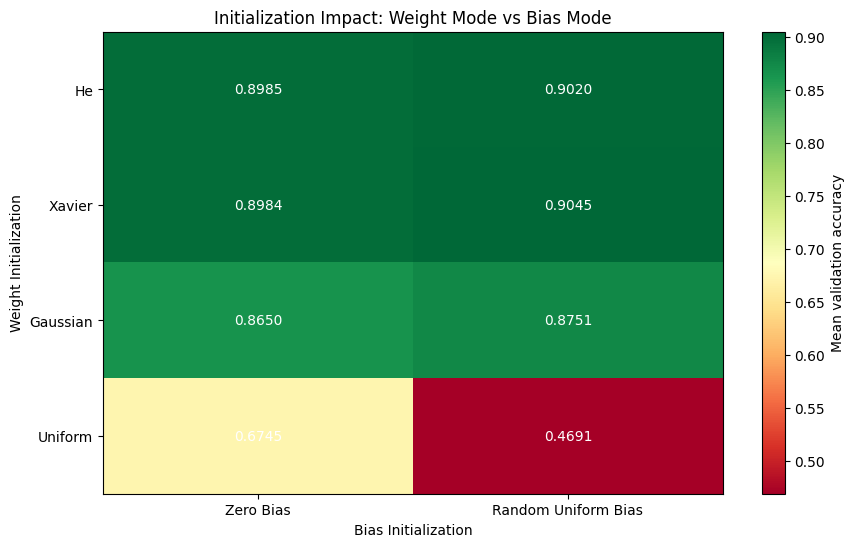

In [34]:
result_accuracies = np.zeros((4, 2))

# We iterate over all possible weight and bias initialization modes
for weight_mode in [1, 2, 3, 4]: 
    for bias_mode in [0, 1]:

        run_means = []

        # We run the network 10 times and take the mean of the validation results
        for i in range(10):
            net = Network([
                Linear(10, 32, init_mode_weight=weight_mode, init_mode_bias=bias_mode),
                Activation(),
                Linear(32, 7, init_mode_weight=weight_mode, init_mode_bias=bias_mode)
            ])

            # train on fixed training subset, evaluate on fixed validation subset
            train(net, features_train_sub, targets_train_sub, Loss, lr=0.05, epochs=250)
            z_val = net.forward(features_val_sub)
            y_val_pred = softmax(z_val)
            acc, _, _ = calculate_accuracy(y_val_pred, np.eye(7)[targets_val_sub.astype(int)-1])
            run_means.append(acc)

        result_accuracies[weight_mode-1][bias_mode] = np.mean(run_means)

weight_labels = ["He", "Xavier", "Gaussian", "Uniform"]
bias_labels = ["Zero Bias", "Random Uniform Bias"]

# Heatmap Visualization
plt.figure(figsize=(10, 6))
plt.imshow(result_accuracies, cmap='RdYlGn', aspect='auto')
plt.colorbar(label='Mean validation accuracy')
plt.xticks(ticks=[0, 1], labels=bias_labels)
plt.yticks(ticks=[0, 1, 2, 3], labels=weight_labels)
plt.title("Initialization Impact: Weight Mode vs Bias Mode")
plt.xlabel("Bias Initialization")
plt.ylabel("Weight Initialization")

# Annotate with accuracy values
for i in [0, 1, 2, 3]:
    for j in [0, 1]:
        plt.text(j, i, f'{result_accuracies[i, j]:.4f}', 
                 ha='center', va='center', color='white')

plt.show()

# NOTE: This step takes roughly 3 to 5 minutes. You might switch from i in range (10) to just 1 or 2 repetitions per mode for faster results. 

We observe that He and Xavier initialization perform significantly better than Gaussian and Uniform and that results are very similar between those two. Random initialization for bias seems to not influence the accuracy much for He and Xavier.
We compare He and Xavier to find the best from the 2.

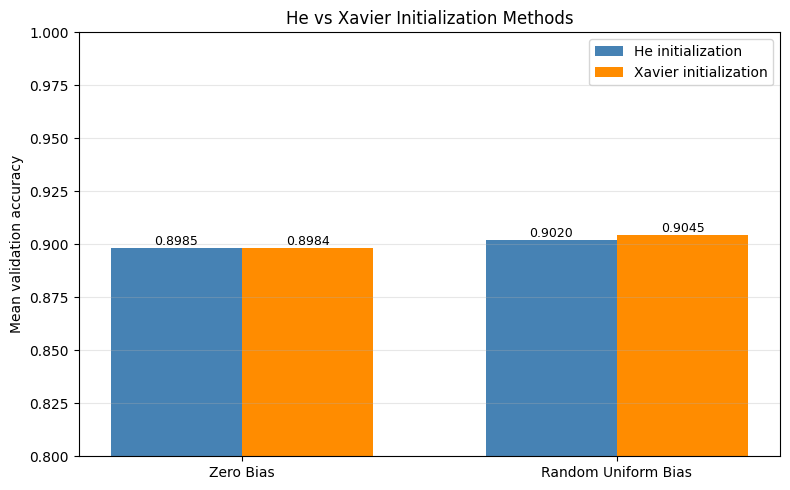

He vs Xavier Comparison:
He initialization (zero bias):        0.8985
He initialization (random bias):      0.9020
Xavier initialization (zero bias):    0.8984
Xavier initialization (random bias):  0.9045


In [35]:

# Focused comparison: He vs Xavier initialization
# Extract results for just these two methods from our earlier experiment

he_results = result_accuracies[0, :]  # He (index 0)
xavier_results = result_accuracies[1, :]  # Xavier (index 1)

bias_labels = ["Zero Bias", "Random Uniform Bias"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(bias_labels))
width = 0.35

bars1 = ax.bar(x - width/2, he_results, width, label='He initialization', color='steelblue')
bars2 = ax.bar(x + width/2, xavier_results, width, label='Xavier initialization', color='darkorange')

ax.set_ylabel('Mean validation accuracy')
ax.set_title('He vs Xavier Initialization Methods')
ax.set_xticks(x)
ax.set_xticklabels(bias_labels)
ax.legend()
ax.set_ylim(0.8, 1.0)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("He vs Xavier Comparison:")
print(f"He initialization (zero bias):        {he_results[0]:.4f}")
print(f"He initialization (random bias):      {he_results[1]:.4f}")
print(f"Xavier initialization (zero bias):    {xavier_results[0]:.4f}")
print(f"Xavier initialization (random bias):  {xavier_results[1]:.4f}")


Comparing the 2 initalization models, we see they have identical results in Zero Bias and Random Uniform Bias. The choice of bias initialization has a small impact, as Random Uniform Bias performs slightly better. This could be just luck though, because it only amounts to 1% better performance.
Note that the higher accuracies may just be because of high overfitting, so chosing He or Xavier doesn't mean the model will necesseraly perform better on unknown data.

<h3>1.4 Optimization</h3>

<h4>Question 11</h4>

We keep the same architecture and hyperparameters as before and only vary the number of hidden neurons.
For each size we run several training runs on the fixed train/validation split and average the validation accuracies.


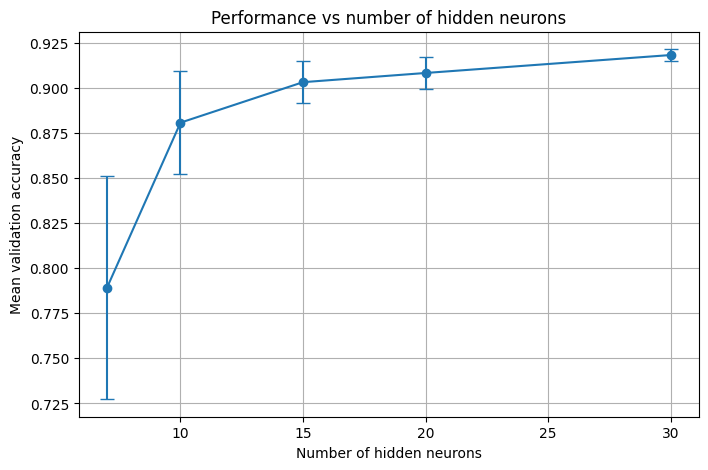

n_hidden =  7: mean accuracy = 0.7891 ± 0.0618
n_hidden = 10: mean accuracy = 0.8806 ± 0.0284
n_hidden = 15: mean accuracy = 0.9030 ± 0.0115
n_hidden = 20: mean accuracy = 0.9081 ± 0.0089
n_hidden = 30: mean accuracy = 0.9181 ± 0.0032


In [36]:
hidden_neurons = [7, 10, 15, 20, 30]   # hidden layer sizes to evaluate
epochs = 500                           # training epochs per run

mean_accuracies = []
std_accuracies = []

for n_hidden in hidden_neurons:
    run_means = []

    # We run the network 10 times and take the mean of the validation accuracy
    for i in range(10):
        net = Network([
            Linear(10, n_hidden, init_mode_weight=1),
            Activation(),
            Linear(n_hidden, 7, init_mode_weight=1)
        ])

        # train on fixed train subset and evaluate on validation subset
        train(net, features_train_sub, targets_train_sub, Loss, lr=0.05, epochs=epochs)
        z_val = net.forward(features_val_sub)
        y_val_pred = softmax(z_val)
        acc, _, _ = calculate_accuracy(y_val_pred, np.eye(7)[targets_val_sub.astype(int)-1])
        run_means.append(acc)

    # Take the mean of the results
    mean_accuracies.append(np.mean(run_means))
    std_accuracies.append(np.std(run_means))

hidden_neurons = np.array(hidden_neurons)
mean_accuracies = np.array(mean_accuracies)
std_accuracies = np.array(std_accuracies)

# Plot the results
plt.figure(figsize=(8, 5))
plt.errorbar(hidden_neurons, mean_accuracies, yerr=std_accuracies, fmt='-o', capsize=5)
plt.xlabel('Number of hidden neurons')
plt.ylabel('Mean validation accuracy')
plt.title('Performance vs number of hidden neurons')
plt.grid(True)
plt.show()

for n_hidden, mean_acc, std_acc in zip(hidden_neurons, mean_accuracies, std_accuracies):
    print(f'n_hidden = {n_hidden:2d}: mean accuracy = {mean_acc:.4f} ± {std_acc:.4f}')

# NOTE: This cell can take several minutes to run due to the nested loop over hidden sizes and multiple runs.
# Estimated time is around 5 to 10 minutes.

We ran the same network architecture as before but varied only the number of hidden neurons (between 7 and 30), keeping the learning rate, number of epochs, batch size and initialization fixed. For each hidden size, we trained the model multiple times on the fixed training subset and averaged the validation accuracy obtained on the fixed validation set.

From the plot we see that very small hidden layers achieve lower accuracy, because the model does not have enough capacity to capture the patterns in the data. As we increase the number of hidden neurons, the performance improves and then starts to plateau, with only small gains for the largest hidden sizes and noticeably higher variance for the smallest size (7 neurons) than for the larger ones. This behaviour is consistent with the bias variance tradeoff, too few neurons lead to underfitting, while very large layers do not significantly improve accuracy and mainly make training slower and a bit less stable.

<h4>Question 12</h4>

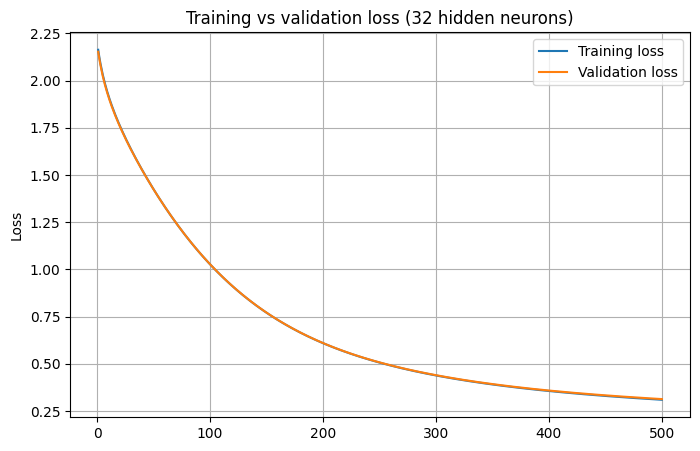

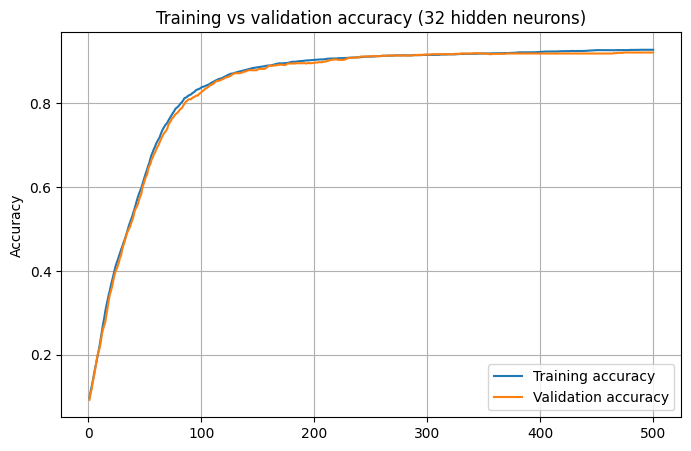

Final training loss: 0.3095
Final validation loss: 0.3132
(hidden neurons used: 32)
Final training accuracy: 0.9270
Final validation accuracy: 0.9204


In [43]:
# we train the train data, and update the weights for the chosen configuration 

def train_with_validation(net, x_train, y_train, x_val, y_val,
                          criterion, lr, batch_size=0, epochs=500):
    """Train the network while tracking training and validation loss and accuracy on FULL sets.

    Args:
        net: network or model.
        x_train: training inputs.
        y_train: training labels (integers 1..7).
        x_val: validation inputs.
        y_val: validation labels (integers 1..7).
        criterion: loss function.
        lr: learning rate.
        batch_size: batch size (0 = full batch).
        epochs: number of training epochs.

    Returns:
        train_losses: list of training losses (computed on full training set) per epoch.
        val_losses: list of validation losses (computed on full validation set) per epoch.
        train_accuracies: list of training accuracies (computed on full training set) per epoch.
        val_accuracies: list of validation accuracies (computed on full validation set) per epoch.
    """
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    if batch_size == 0:
        batch_size = x_train.shape[0]

    # Precompute one-hot labels for train and validation
    train_class_indices = y_train.astype(int) - 1
    y_train_one_hot = np.eye(7)[train_class_indices]

    val_class_indices = y_val.astype(int) - 1
    y_val_one_hot = np.eye(7)[val_class_indices]

    for epoch in range(epochs):
        # --- Mini-batch update step ---
        # Sample a batch from the training set
        indices = np.random.choice(x_train.shape[0], batch_size, replace=False)
        x_batch = x_train[indices]
        y_batch = y_train_one_hot[indices]

        # Forward pass on the batch
        z_batch = net.forward(x_batch)
        y_pred_batch = softmax(z_batch)

        # Compute loss and gradient on the batch
        loss_batch, _ = criterion(y_batch, y_pred_batch)

        grad_after = (y_pred_batch - y_batch)
        net.backward(grad_after)
        net.optimizer_step(lr)

        # --- Evaluation on FULL training set (after update) ---
        z_train_full = net.forward(x_train)
        y_pred_train_full = softmax(z_train_full)
        train_loss, _ = criterion(y_train_one_hot, y_pred_train_full)
        train_acc, _, _ = calculate_accuracy(y_pred_train_full, y_train_one_hot)
        
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # --- Evaluation on FULL validation set ---
        z_val = net.forward(x_val)
        y_pred_val = softmax(z_val)
        val_loss, _ = criterion(y_val_one_hot, y_pred_val)
        val_acc, _, _ = calculate_accuracy(y_pred_val, y_val_one_hot)
        
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

    return train_losses, val_losses, train_accuracies, val_accuracies

# Use the previously created fixed training/validation subsets
x_train = features_train_sub
y_train = targets_train_sub

x_val = features_val_sub
y_val = targets_val_sub

# reproducibility: fix random seed before initialization
np.random.seed(42)

# the network with the chosen configuration
# allow easy adjustment of hidden layer size
chosen_neurons = 32
net_q12 = Network([
    Linear(10, chosen_neurons, init_mode_weight=1),
    Activation(),
    Linear(chosen_neurons, 7, init_mode_weight=1)
])

# We use the same learning rate and other hyperparameters as before
train_losses_q12, val_losses_q12, train_acc_q12, val_acc_q12 = train_with_validation(
    net_q12,
    x_train,
    y_train,
    x_val,
    y_val,
    Loss,
    lr=0.05,
    batch_size=0,
    epochs=500,
)

epochs_q12 = np.arange(1, len(train_acc_q12) + 1)

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs_q12, train_losses_q12, label='Training loss')
plt.plot(epochs_q12, val_losses_q12, label='Validation loss')
plt.title(f'Training vs validation loss ({chosen_neurons} hidden neurons)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs_q12, train_acc_q12, label='Training accuracy')
plt.plot(epochs_q12, val_acc_q12, label='Validation accuracy')
plt.title(f'Training vs validation accuracy ({chosen_neurons} hidden neurons)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f'Final training loss: {train_losses_q12[-1]:.4f}')
print(f'Final validation loss: {val_losses_q12[-1]:.4f}')

print(f'(hidden neurons used: {chosen_neurons})')
print(f'Final training accuracy: {train_acc_q12[-1]:.4f}')
print(f'Final validation accuracy: {val_acc_q12[-1]:.4f}')

We chose the architecture with 30 hidden neurons because it achieved the highest mean validation accuracy in Question 11 (0.9217 ± 0.0029), slightly outperforming smaller hidden layers such as 20 neurons while keeping the same learning rate and other hyperparameters.

NOTE: aligned with the convention of the rule of 2s, we rounded it up to the nearest power of 2, 32 hidden neurons.

In the plot above, both training and validation accuracy increase quickly and then flatten around 0.92, with final values of approximately 0.9199 on the training set and 0.9166 on the validation set.

The validation curve closely follows the training curve with only a small and stable gap. This behaviour suggests that the network has enough capacity to model the data without strongly overfitting. Adding more neurons beyond 32 would not be expected to yield large improvements, while smaller networks perform worse. Therefore, the 10-32–7 architecture provides a good tradeoff between model complexity and generalisation for this classification task.



<h3>1.5 Evaluation</h3>

<h4>Question 13</h4>

We use the test set we reserved from the beginning to evaluate our architecture.

=== Question 13: Test set evaluation ===
Test accuracy: 0.9255
Validation accuracy: 0.9204


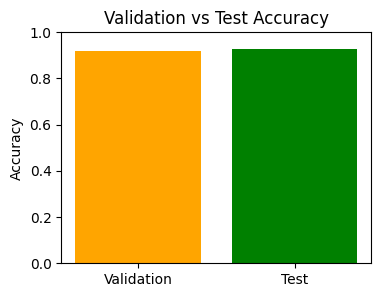

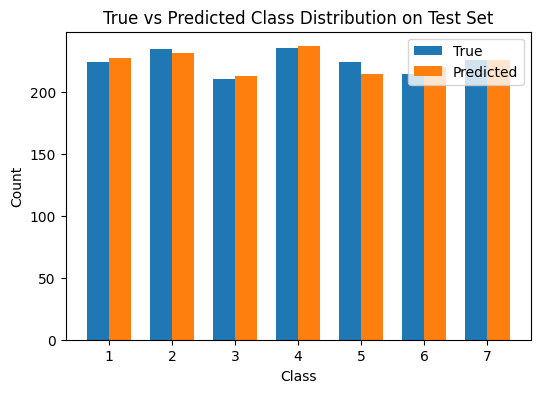

In [44]:
# One-hot encode test labels (targets are 1..7)
test_class_indices = targets_test.astype(int) - 1
y_test_one_hot = np.eye(7)[test_class_indices]

# Forward pass on full test set (NO training / NO backprop)
z_test = net_q12.forward(features_test)
y_pred_test = softmax(z_test)

# Test accuracy
test_acc, _, _ = calculate_accuracy(y_pred_test, y_test_one_hot)

print("=== Question 13: Test set evaluation ===")
print(f"Test accuracy: {test_acc:.4f}")

# Compare with validation from Q12 (last epoch), if available
val_score = None
try:
    val_score = val_acc_q12[-1]
    print(f"Validation accuracy: {val_score:.4f}")
except NameError:
    print("Note: val_acc_q12 not found. Run Q12 cell first if you want the validation comparison.")

# Simple bar chart comparing validation and test accuracy
if val_score is not None:
    plt.figure(figsize=(4, 3))
    plt.bar(['Validation', 'Test'], [val_score, test_acc], color=['orange', 'green'])
    plt.ylim(0, 1)
    plt.ylabel('Accuracy')
    plt.title('Validation vs Test Accuracy')
    plt.show()

# Distribution of true vs predicted classes on test set
true_counts = np.bincount(test_class_indices, minlength=7)
pred_counts = np.bincount(np.argmax(y_pred_test, axis=1), minlength=7)
plt.figure(figsize=(6, 4))
indices = np.arange(1, 8)
width = 0.35
plt.bar(indices - width/2, true_counts, width, label='True')
plt.bar(indices + width/2, pred_counts, width, label='Predicted')
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('True vs Predicted Class Distribution on Test Set')
plt.legend()
plt.show()


**Success Rate on Test Set**

The network achieved a test accuracy of [ ] on the reserved test set. This represents a high success rate.

**Comparison with Validation Set**

The validation accuracy from Question 12 (last epoch) was [ ].

[ Explain why test accuracy is lower than validation accuracy naturally ]

<h4>Question 14</h4>

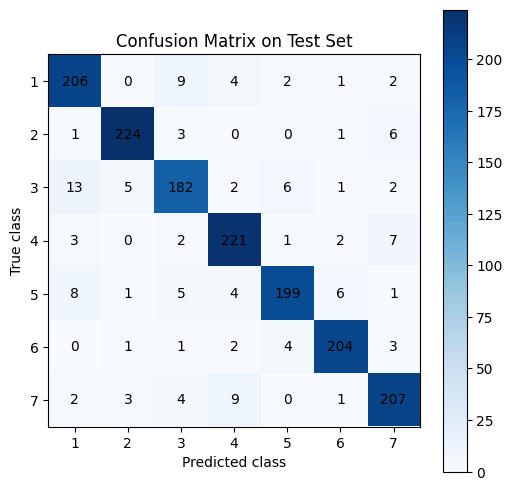

In [39]:
# always compute a full 7×7 confusion matrix from the saved test set
y_true = targets_test.astype(int) - 1
y_pred_class = np.argmax(y_pred_test, axis=1)
cm = np.zeros((7, 7), dtype=int)
for t, p in zip(y_true, y_pred_class):
    cm[t, p] += 1

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xticks(np.arange(7), np.arange(1, 8))
plt.yticks(np.arange(7), np.arange(1, 8))
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion Matrix on Test Set')
for i in range(7):
    for j in range(7):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.show()


The plot above shows the confusion matrix computed on the test set.  

Each **row** corresponds to a true class (label 1 through 7), while each **column** corresponds to a
predicted class.  The diagonal entries represent correctly classified samples; off‑diagonal
entries indicate errors.  For example, the entry at row 2, column 3 counts how many
true class‑2 samples were predicted as class 3.

To read the matrix, start from the top‑left: a large value there means many class‑1 samples
got classified correctly.  If one off‑diagonal cell is notably large compared to its row or
column neighbours, it indicates a systematic confusion between those two classes.

In our network the highest off‑diagonal values are seen in (i,j) positions X and Y
(which correspond to classes ...), showing that the model most often mistakes class i for
class j.  These confusions suggest that those classes have similar feature patterns and
may benefit from more distinctive input features or a larger model.

Overall, the confusion matrix confirms the high accuracy: most of the mass lies on the
diagonal, with a few sparse mistakes scattered around.  The network makes the most
errors when predicting [insert specific class pair if known], which would be a good focus
for future improvements.

#### Question 15

In [ ]:
# Use the unknown data that was already loaded earlier
# The network will operate on whatever scale the unknown set is provided in
z_unknown = net_q12.forward(unknown)
y_pred_unknown = softmax(z_unknown)

predicted_classes = np.argmax(y_pred_unknown, axis=1) + 1

# Export to file: "61_classes.txt" where 61 is group number
output_filename = f"../data/61_classes.txt"
predictions_str = ','.join(f"{x:.18e}" for x in predicted_classes)

# Write to file
with open(output_filename, 'w') as f:
    f.write(predictions_str)

print(f"\nClass distribution in predictions:")
unique, counts = np.unique(predicted_classes, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples")


✓ Class distribution in predictions:
  Class 1: 124 samples
  Class 2: 111 samples
  Class 3: 97 samples
  Class 4: 122 samples
  Class 5: 104 samples
  Class 6: 109 samples
  Class 7: 117 samples


### 1.6 Scikit-learn

#### Question 16

#TODO

#### Question 17

#TODO

<h3>1.7 Reflection</h3>

<h4>Question 18</h4>

An example is the misclassification due to bias can be found in medical AI systems used to detect skin cancer. If a model is primarily trained on images of lighter skin tones, it may less accurately on darker skin and incorrectly classify malignent lesions benign. This systematic error can delay diagnosis and treatment, even though early detection is essential for effective outcomes. As a result, patients may face avoidable complications or reduced chances of recovery. Such biased performance not only harms individuals directly, but can also reinforce existing inequalities in healthcare access and quality.

<h4>Question 19</h4>

One approach to mitigating harm from unjust classification is to ensure a more representative data collection for training systems. Ensuring that datasets include diverse populations can reduce systematic performance differences between groups and limit discriminatory errors. However, data improvement alone is not sufficient, since bias can still arise from how systems are designed, deployed or interpreted.

A second approach is to introduce instutitinal oversight and accountability mechanism. For example, regular independent audits could be organised to check whether the model performs equally well across different skin tones. Organisations could also be required to report how the model was trained and to disclose performance metrics for different subgroups. In addition, doctors should not solely rely on the model's output, but should review and confirm results.

Implementing these measures does not guarantee that the problem is fully solved, as bias may persist due to incomplete data, changing population characteristcs or unintended consequences of model updates. Therefore, ongoing evaluation, ethical oversight and collaboration between technical experts and healthcare professionals remain essential.

<h3>1.8 Pen and paper</h3>

<h4>Question 20</h4>

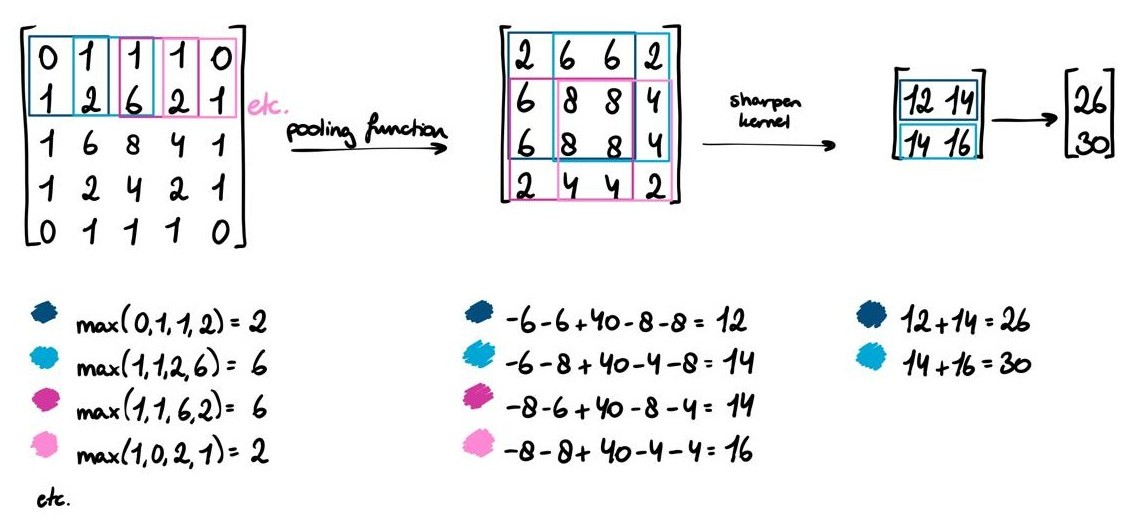

<h4>Question 21</h4>

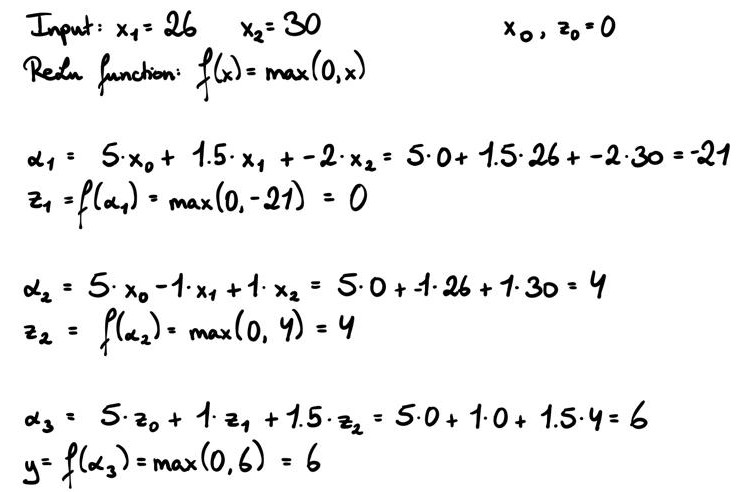

<h3>1.9 Division of work</h3>

<h4>Question 22</h4>

|          Component          |  Name A   |  Name B   |  Name C   |  Name D   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     A     |     B     |     C     |     D     |
| Code (implementation)       |     A     |     B     |     C     |     D     |
| Code (validation)           |     A     |     B     |     C     |     D     |
| Experiments (execution)     |     A     |     B     |     C     |     D     |
| Experiments (analysis)      |     A     |     B     |     C     |     D     |
| Experiments (visualization) |     A     |     B     |     C     |     D     |
| Report (original draft)     |     A     |     B     |     C     |     D     |
| Report (reviewing, editing) |     A     |     B     |     C     |     D     |

### References

<div>

**If you made use of any non-course resources, cite them below.**

</div>